<a href="https://colab.research.google.com/github/yshzjq/Step-2.Statistical_Thinking-Machine-Learning/blob/main/Step%202.%20%ED%86%B5%EA%B3%84%EC%A0%81%20%EC%82%AC%EA%B3%A0%EC%99%80%20%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%20%EC%9E%85%EB%AC%B8/2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
 # 데이터 처리용
import pandas as pd
import numpy as np

# 시각화용
import matplotlib.pyplot as plt
import seaborn as sns

# 머신러닝 관련
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression # 선형회귀
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [9]:
# Bike Sharing Demand 데이터
url ="/content/train.csv"

# CSV 파일 읽기
df = pd.read_csv(url)

df.head()



,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [10]:
# datetime 컬럼을 datetime 타입으로 변환
df['datetime'] = pd.to_datetime(df['datetime'])

# datetime 분해
df['year']   = df['datetime'].dt.year
df['month']  = df['datetime'].dt.month
df['day']    = df['datetime'].dt.day
df['hour']   = df['datetime'].dt.hour
df['minute'] = df['datetime'].dt.minute
df['second'] = df['datetime'].dt.second

df


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011,1,1,0,0,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011,1,1,1,0,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011,1,1,2,0,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011,1,1,3,0,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011,1,1,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012,12,19,19,0,0
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012,12,19,20,0,0
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012,12,19,21,0,0
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012,12,19,22,0,0


In [11]:
# 예측에 사용할 입력 변수 선택
features = [
'temp',# 온도
'humidity',# 습도
'windspeed',# 풍속
'hour'# 시간
]

# 입력(X)과 정답(y) 분리
X = df[features]
y = df['count']# 대여량

print(X.shape)
print(y.shape)

(10886, 4)
(10886,)


In [12]:
# 데이터 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
# 선형회귀 모델 생성
model = LinearRegression()



In [14]:
# 모델 학습
model.fit(X_train, y_train)



LinearRegression()

In [15]:
# 테스트 데이터로 예측
y_pred = model.predict(X_test)

y_pred[:5]

array([298.3238875 ,  40.67178023, 188.61548431, 250.73364991,
       336.88050777])

In [16]:
# MAE 계산
mae = mean_absolute_error(y_test, y_pred)

# MSE 계산
mse = mean_squared_error(y_test, y_pred)

# RMSE 계산
rmse = np.sqrt(mse)

# r2 계산
r2 = r2_score(y_test, y_pred)

mae, mse, rmse, r2



(108.6513779800835,
 22198.268417833915,
 np.float64(148.99083333492),
 0.3274665510121463)

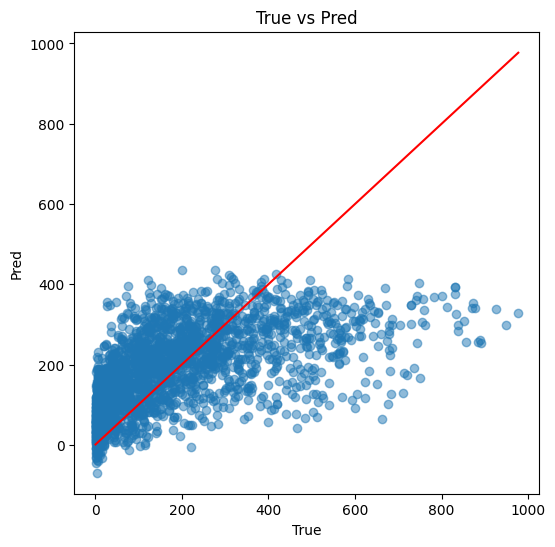

In [17]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("True")
plt.ylabel("Pred")
plt.title("True vs Pred")

# 기준선 (완벽한 예측일 경우)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()



In [18]:
# 회귀 계수 확인
coef_df = pd.DataFrame({
'feature': features,
'coefficient': model.coef_
})

coef_df



,feature,coefficient
0,temp,7.729721
1,humidity,-2.019060
2,windspeed,-0.163426
3,hour,7.716990


In [19]:
# 학습 데이터 성능
train_pred = model.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = rmse

train_rmse, test_rmse

# MSE 계산
mse = mean_squared_error(y_test, y_pred)



(np.float64(149.70271321994946), np.float64(148.99083333492))